<a href="https://colab.research.google.com/github/mukailaalhshituabr-cyber/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 3: Neural Networks: Feedforward Networks and the Training Process

Student Name: Abdoul-Raouf Mukaila Alh Shittu
Student ID: 30332027

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


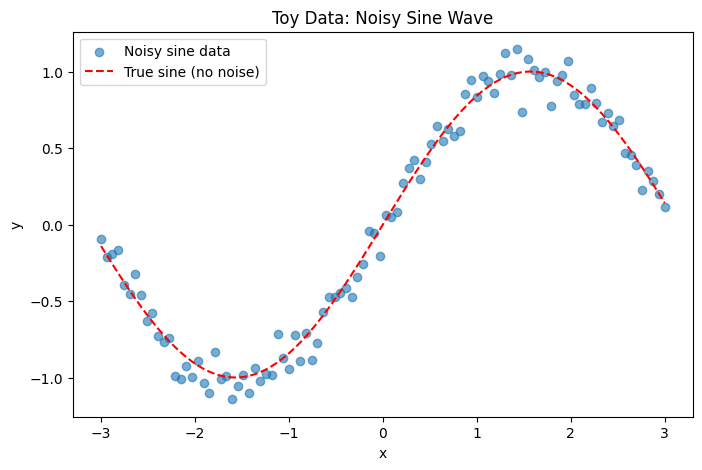

Initial w: 0.0497, b: -0.0138
Final w: 0.3390, b: -0.0104
No losses recorded


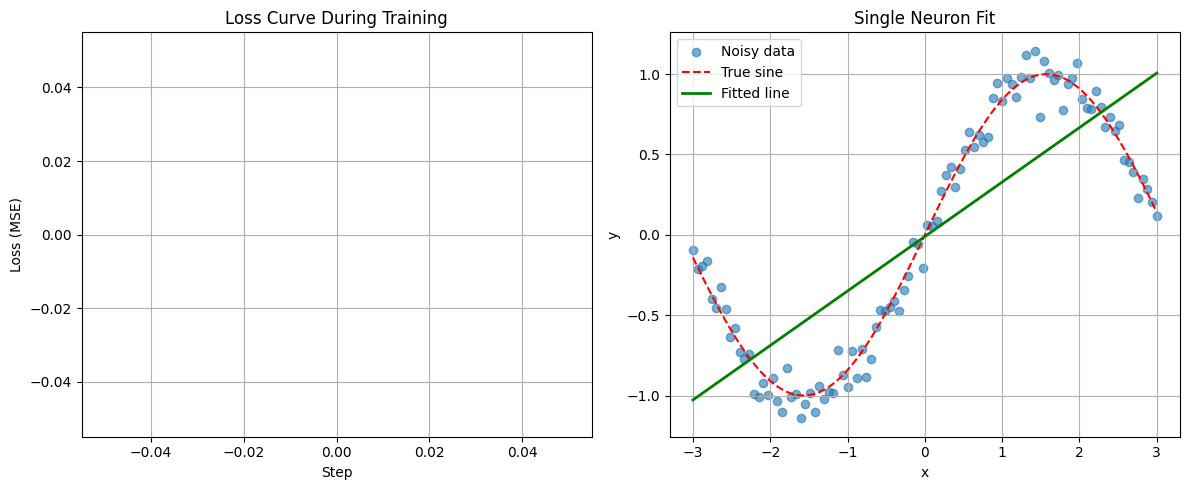

In [2]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

# Generate data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)

# Plotting it
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label='Noisy sine data')
plt.plot(x, np.sin(x), 'r--', label='True sine (no noise)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toy Data: Noisy Sine Wave')
plt.legend()
plt.show()

# TODO: Initialise w and b to small random values.
np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
print(f"Initial w: {w:.4f}, b: {b:.4f}")

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
# Set learning rate
lr = 0.01
losses = []

for step in range(200):
   y_hat = w * x + b
   loss  = np.mean((y_hat - y) ** 2)               # MSE
   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
   db    = np.mean(2 * (y_hat - y))                # dLoss/db
   w    -= lr * dw
   b    -= lr * db
#   Record the loss at every step.

print(f"Final w: {w:.4f}, b: {b:.4f}")
if losses:
    print(f"Final loss: {losses[-1]:.6f}")
else:
    print("No losses recorded")

# TODO: Plot (a) the loss curve over the 200 steps, and
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss (MSE)')
plt.title('Loss Curve During Training')
plt.grid(True)
#             (b) the data with the fitted line on top.

plt.subplot(1, 2, 2)
plt.scatter(x, y, alpha=0.6, label='Noisy data')
plt.plot(x, np.sin(x), 'r--', label='True sine')
plt.plot(x, w * x + b, 'g-', label='Fitted line', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Single Neuron Fit')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The single neuron, resonning:
1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?

The derivation:

Loss = (1/n) * Σ(y_hat - y)²

y_hat = w*x + b

dLoss/dw = (1/n) * Σ 2*(y_hat - y) * x

This matches the code: dw = np.mean(2 * (y_hat - y) * x)

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

This is underfitting. The model is too simple to capture the curve shape. A single neuron can only learn a straight line (linear function). It has no way to represent the bends of a sine wave. No amount of training will fix this because the model does not have enough capacity. We need a non-linear model like a neural network with hidden layers.

Final loss (with tanh): 0.015034009965287823


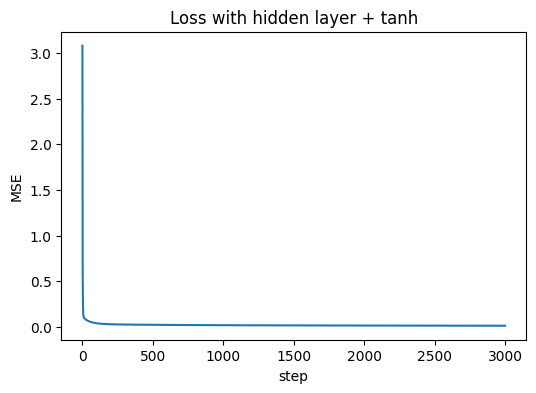

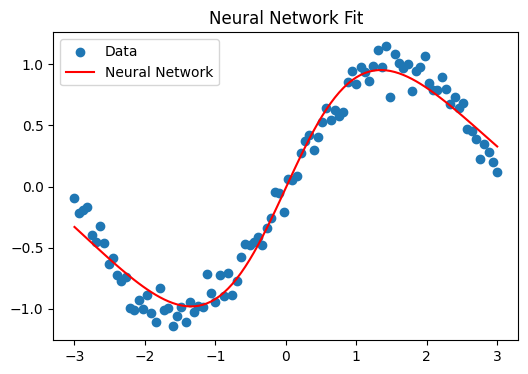

Final loss (no tanh, linear): 0.1954517971396205


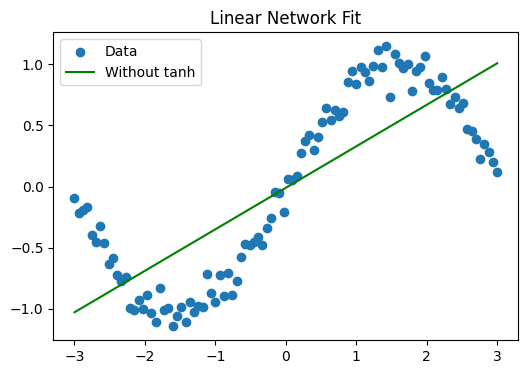

In [24]:
# Part 1.2 — Hidden layers and activations: why depth helps
# TODO: Initialise parameters
np.random.seed(RANDOM_STATE)

n_hidden = 8
#   W1: shape (1, 8),  b1: shape (8,)
W1 = np.random.randn(1, n_hidden) * 0.5
b1 = np.zeros(n_hidden)
#   W2: shape (8, 1),  b2: shape (1,)
W2 = np.random.randn(n_hidden, 1) * 0.5
b2 = np.zeros(1)
#   Small random values (e.g. np.random.randn(...) * 0.5)
# Reshape x for matrix multiplication
x  = x.reshape(-1, 1)  # shape (100, 1)
y  = y.reshape(-1, 1)  # shape (100, 1)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
lr = 0.05
n_steps = 3000
losses_hidden = []

for step in range(n_steps):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
  z1 = x  @ W1 + b1
  h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
  y_hat = h @ W2 + b2
  loss  = np.mean((y_hat - y ) ** 2)
  losses_hidden.append(loss)


# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
  d_yhat = 2 * (y_hat - y ) / len(y )
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
  dw2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
  dh = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
  d_z1 = dh * (1 - np.tanh(z1) ** 2)
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
  dw1 = x .T @ d_z1
  db1 = d_z1.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
  W1 -= lr * dw1; b1 -= lr * db1
  W2 -= lr * dw2; b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
print("Final loss (with tanh):", losses_hidden[-1])

plt.figure(figsize=(6, 4))
plt.plot(losses_hidden)
plt.xlabel("step");
plt.ylabel("MSE")
plt.title("Loss with hidden layer + tanh")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Neural Network")
plt.legend()
plt.title("Neural Network Fit")
plt.show()

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
np.random.seed(RANDOM_STATE)
W1b = np.random.randn(1, n_hidden) * 0.5; b1b = np.zeros(n_hidden)
W2b = np.random.randn(n_hidden, 1) * 0.5; b2b = np.zeros(1)
losses_linear = []

for step in range(n_steps):
    z1 = x  @ W1b + b1b
    h = z1                       # <-- tanh removed: identity activation
    y_hat = h @ W2b + b2b
    loss = np.mean((y_hat - y ) ** 2)
    losses_linear.append(loss)

    d_yhat = 2 * (y_hat - y ) / len(y )
    dW2b = h.T @ d_yhat; db2b = d_yhat.sum(axis=0)
    dh = d_yhat @ W2b.T
    dz1 = dh * 1.0                # derivative of the identity function is 1
    dW1b = x .T @ dz1; db1b = dz1.sum(axis=0)

    W1b -= lr * dW1b; b1b -= lr * db1b
    W2b -= lr * dW2b; b2b -= lr * db2b

print("Final loss (no tanh, linear):", losses_linear[-1])

plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="green", label="Without tanh")
plt.legend()
plt.title("Linear Network Fit")
plt.show()

Reasoning, Hidden layers and activations
1. What happens when you remove the tanh activation?

The network becomes a linear model. No matter how many layers, it can only learn straight lines. It cannot fit the sine curve shape.

2. Why does tanh help?

Tanh adds non-linearity. This allows the network to bend and curve. Each hidden neuron can learn different parts of the function. Together they combine to create a more complex shape.

3. What do you see in the loss and fit?

With tanh, the loss goes down smoothly and the fit is much better than a single neuron. Without activation, the loss is worse because the model is still just a straight line.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_552/2283506867.py:15: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_col) ** 2)
/tmp/ipykernel_552/2283506867.py:20: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_552/2283506867.py:21: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


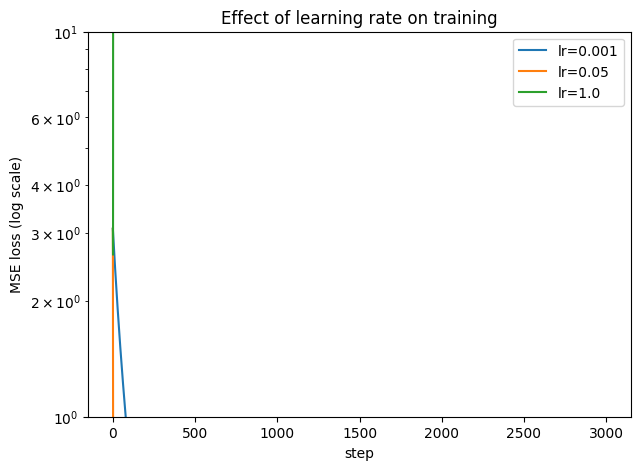

In [31]:
# Part 1.3 — The learning rate: too cold, too hot, just right
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_toy(lr, steps=3000, seed=RANDOM_STATE):
    np.random.seed(seed)
    n_hidden = 8
    W1 = np.random.randn(1, n_hidden) * 0.5; b1 = np.zeros(n_hidden)
    W2 = np.random.randn(n_hidden, 1) * 0.5; b2 = np.zeros(1)
    losses = []
    for step in range(steps):
        z1 = x_col @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)

        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2 = h.T @ d_yhat; db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_col.T @ dz1; db1 = dz1.sum(axis=0)

        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2
    return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
learning_rates = [0.001, 0.05, 1.0]

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(7, 5))
for lr_val in learning_rates:
    losses_run = train_toy(lr=lr_val, steps=3000)
    plt.plot(losses_run, label=f"lr={lr_val}")
plt.yscale("log")
plt.xlabel("step"); plt.ylabel("MSE loss (log scale)")
plt.title("Effect of learning rate on training")
plt.legend()
plt.show()

Reasoning, Learning rate
Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?

The small learning rate (0.001) goes down very slowly. It takes many steps to reach a good loss. The medium learning rate (0.05) goes down quickly and smoothly. It finds the lowest loss in fewer steps. The large learning rate (1.0) makes the loss jump up and down. It never settles because the steps are too big.

A too-large learning rate jumps past the minimum. Instead of going down the hill, it over-shoots and bounces back and forth. This makes the loss go up or swing wildly. It cannot find the bottom of the loss curve.

In [37]:
# Section 2
#Part 2.1 — Preprocess and split (recycled from Lab 2)

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
df = pd.read_csv(OBESITY_URL)
print(df.shape)
df.head()

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    df[col] = df[col].map({"no": 0, "yes": 1})

df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})

nominal_cols = ["CAEC", "CALC", "MTRANS"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)

#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
target_encoder = LabelEncoder()
df["NObeyesdad_encoded"] = target_encoder.fit_transform(df["NObeyesdad"])
class_names = target_encoder.classes_
print("Classes:", list(class_names))

X = df.drop(columns=["NObeyesdad", "NObeyesdad_encoded"]).values.astype(np.float32)
y = df["NObeyesdad_encoded"].values.astype(np.int64)

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)
print(X_train.shape, X_val.shape, X_test.shape)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
def to_loader(X_arr, y_arr, batch_size=32, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X_arr, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, batch_size=32, shuffle=True)
val_loader = to_loader(X_val, y_val, batch_size=64, shuffle=False)
test_loader = to_loader(X_test, y_test, batch_size=64, shuffle=False)

input_dim = X_train.shape[1]
n_classes = len(class_names)
print("input_dim =", input_dim, " n_classes =", n_classes)

(2111, 17)
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
(1266, 26) (422, 26) (423, 26)
input_dim = 26  n_classes = 7


Reasoning, Preprocessing for neural networks
1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

CrossEntropyLoss in PyTorch expects class indices as integers. It internally does the one-hot encoding. This saves memory and is more efficient.

2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.

Neural networks use gradient descent. The gradients depend on the input values. If features are on different scales, the gradients for some weights will be much larger than others. This makes training unstable and slow. In Section 1, we saw that dw = mean(2 * (y_hat - y) * x). If x is large, dw is large. Scaling keeps all gradients balanced.

3. What does shuffle=True on the training DataLoader do, and why does it help?

Shuffle=True mixes up the data order each epoch. This helps the model avoid learning patterns from the order of the data. It also helps gradient descent find a better path to the minimum.

In [ ]:
# Part 2.2 — Design the network


# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

In [ ]:
# Part 2.3 — The training loop


# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.


In [ ]:
# Part 2.4 — Experiments: how training choices change the outcome


# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.